In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

from skimage.metrics import structural_similarity, mean_squared_error

def gauss_noise(image, mean=0, stddev=25):
    noise = np.zeros(image.shape, np.uint8)
    cv2.randn(noise, mean, stddev)
    noisy_image = cv2.add(image, noise)
    return noisy_image


def salt_pepper_noise(image, rng_range=101, pepper_value=0, salt_value=100):
    noise = np.random.randint(0, rng_range,size=(image.shape[0], image.shape[1]),dtype=int)
    zeros_pixel = np.where(noise == pepper_value)
    ones_pixel = np.where(noise == salt_value)

    noisy_image = copy.deepcopy(image)
    noisy_image[zeros_pixel] = 0
    noisy_image[ones_pixel] = 255
    return noisy_image


img_gray = cv2.imread('object.jpg', cv2.IMREAD_GRAYSCALE)

Гаусс

In [ ]:
#Гаусс

image_noise_gauss = gauss_noise(img_gray, mean=0, stddev=100)


image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)

image_gauss_bilateral = cv2.bilateralFilter(image_noise_gauss, 9, 150, 9)

image_gauss_nl_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)

image_gauss_nl_30 = cv2.fastNlMeansDenoising(image_noise_gauss, h=30)

image_gauss_nl_50 = cv2.fastNlMeansDenoising(image_noise_gauss, h=50)

plt.figure(figsize=(14, 8))
plt.title('Гаусс', fontsize=24)
plt.axis('off')

plt.subplot(2, 4, 1)
plt.title('Original')
plt.axis('off')
plt.imshow(img_gray, cmap='gray')

print(f"Gauss:")

mse_sp = mean_squared_error(img_gray, image_noise_gauss)
ssim_sp = structural_similarity(img_gray, image_noise_gauss)
print(f"{'Noisy'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 2)
plt.title('Noisy')
plt.axis('off')
plt.imshow(image_noise_gauss, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_gauss_median)
ssim_sp = structural_similarity(img_gray, image_gauss_median)
print(f"{'Median'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 3)
plt.title('Median')
plt.axis('off')
plt.imshow(image_gauss_median, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_gauss_gauss)
ssim_sp = structural_similarity(img_gray, image_gauss_gauss)
print(f"{'Gauss'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 4)
plt.title('Gauss')
plt.axis('off')
plt.imshow(image_gauss_gauss, cmap='gray')


mse_sp = mean_squared_error(img_gray, image_gauss_bilateral)
ssim_sp = structural_similarity(img_gray, image_gauss_bilateral)
print(f"{'Bilateral'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 5)
plt.title('Bilateral')
plt.axis('off')
plt.imshow(image_gauss_bilateral, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_gauss_nl_10)
ssim_sp = structural_similarity(img_gray, image_gauss_nl_10)
print(f"{'NLM 10'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 6)
plt.title('NLM 10')
plt.axis('off')
plt.imshow(image_gauss_nl_10, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_gauss_nl_30)
ssim_sp = structural_similarity(img_gray, image_gauss_nl_30)
print(f"{'NLM 30'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 7)
plt.title('NLM 30')
plt.axis('off')
plt.imshow(image_gauss_nl_30, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_gauss_nl_50)
ssim_sp = structural_similarity(img_gray, image_gauss_nl_50)
print(f"{'NLM 50'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 8)
plt.title('NLM 50')
plt.axis('off')
plt.imshow(image_gauss_nl_50, cmap='gray')

plt.show()

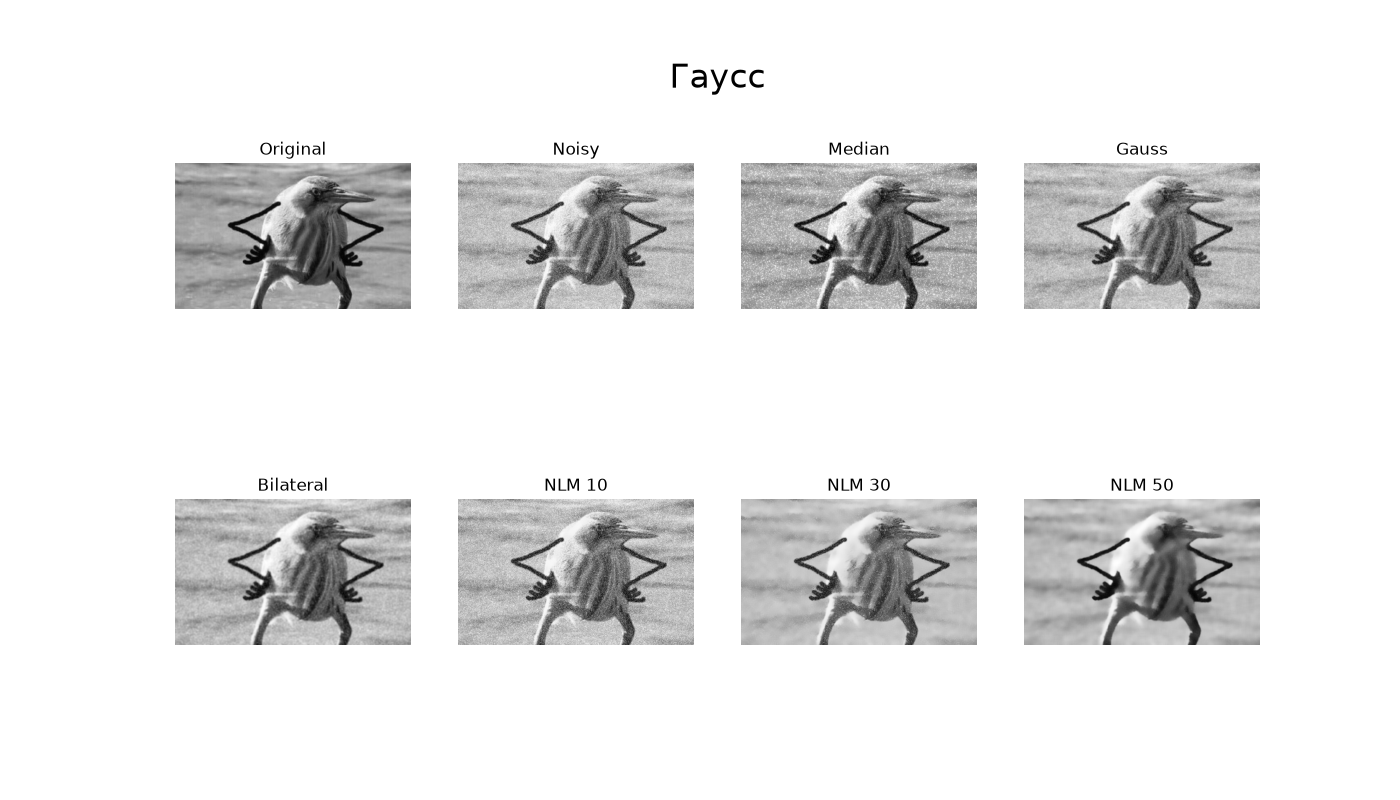
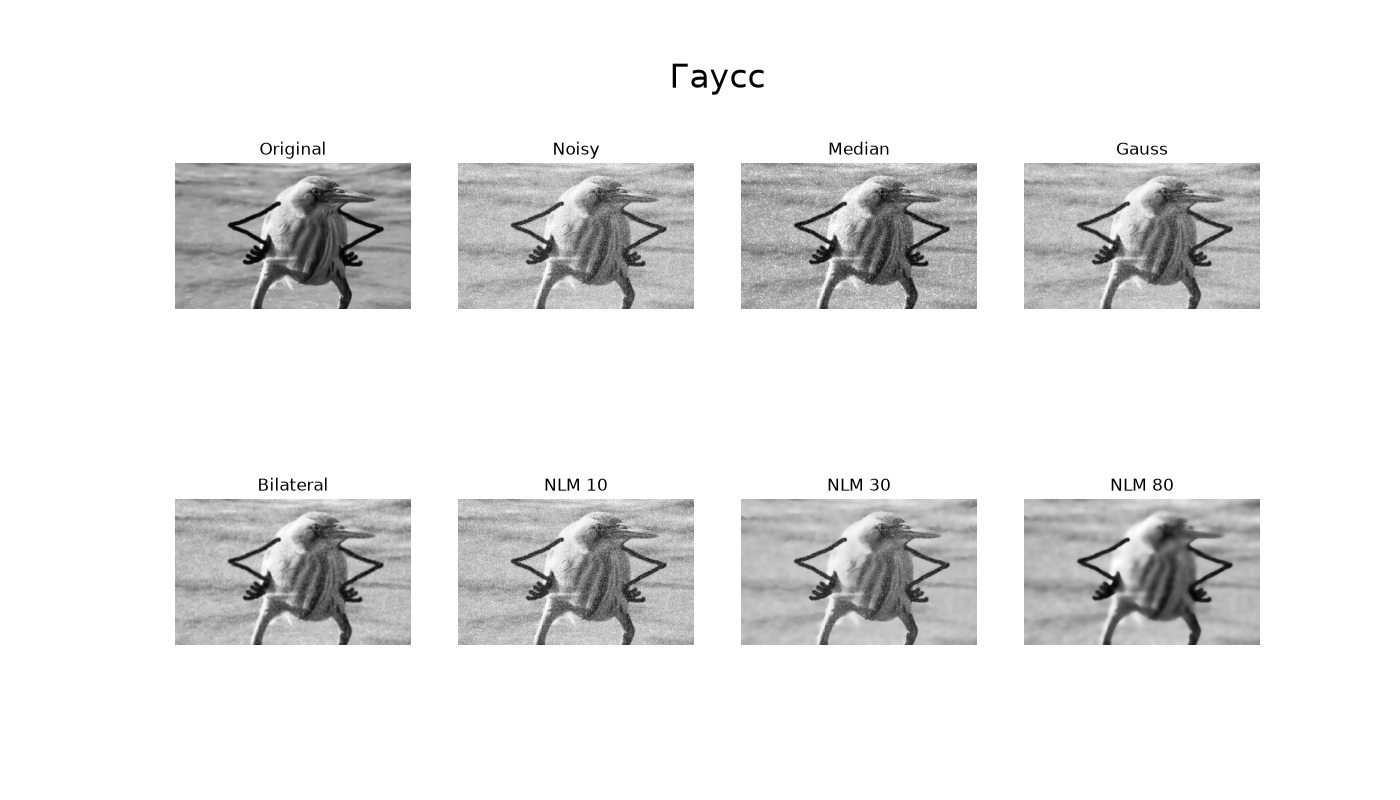

In [ ]:
#Gauss:
#Noisy SSIM: 0.098 MSE: 2880.902
#Median SSIM: 0.275 MSE: 809.164
#Gauss SSIM: 0.495 MSE: 1204.882
#Bilateral SSIM: 0.678 MSE: 1050.367
#NLM 10 SSIM: 0.104 MSE: 2878.786
#NLM 30 SSIM: 0.533 MSE: 1498.909
#NLM 80 SSIM: 0.759 MSE: 1194.167

Соль и Перец

In [ ]:
#Соль и Перец

image_noise_sp = salt_pepper_noise(img_gray)

image_sp_median    = cv2.medianBlur(image_noise_sp, 3)
image_sp_gauss     = cv2.GaussianBlur(image_noise_sp, (5, 5), 0)
image_sp_bilateral = cv2.bilateralFilter(image_noise_sp, 9, 150, 9)
image_sp_nl_10     = cv2.fastNlMeansDenoising(image_noise_sp, h=10)
image_sp_nl_30     = cv2.fastNlMeansDenoising(image_noise_sp, h=30)
image_sp_nl_50     = cv2.fastNlMeansDenoising(image_noise_sp, h=50)
image_sp_nl_80     = cv2.fastNlMeansDenoising(image_noise_sp, h=80)

plt.figure(figsize=(14, 8))
plt.suptitle('Соль и перец', fontsize=20)


plt.subplot(2, 4, 1)
plt.title('Original')
plt.axis('off')
plt.imshow(img_gray, cmap='gray')

print(f"Salt and Pepper:")
mse_sp = mean_squared_error(img_gray, image_noise_sp)
ssim_sp = structural_similarity(img_gray, image_noise_sp)
print(f"{'Noisy'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 2)
plt.title('Noisy')
plt.axis('off')
plt.imshow(image_noise_sp, cmap='gray')


mse_sp = mean_squared_error(img_gray, image_sp_median)
ssim_sp = structural_similarity(img_gray, image_sp_median)
print(f"{'Median'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 3)
plt.title('Median')
plt.axis('off')
plt.imshow(image_sp_median, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_sp_gauss)
ssim_sp = structural_similarity(img_gray, image_sp_gauss)
print(f"{'Gauss'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 4)
plt.title('Gauss')
plt.axis('off')
plt.imshow(image_sp_gauss, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_sp_bilateral)
ssim_sp = structural_similarity(img_gray, image_sp_bilateral)
print(f"{'Bilateral'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 5)
plt.title('Bilateral')
plt.axis('off')
plt.imshow(image_sp_bilateral, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_sp_nl_10)
ssim_sp = structural_similarity(img_gray, image_sp_nl_10)
print(f"{'NLM 10'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 6)
plt.title('NLM 10')
plt.axis('off')
plt.imshow(image_sp_nl_10, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_sp_nl_30)
ssim_sp = structural_similarity(img_gray, image_sp_nl_30)
print(f"{'NLM 30'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 7)
plt.title('NLM 30')
plt.axis('off')
plt.imshow(image_sp_nl_30, cmap='gray')

mse_sp = mean_squared_error(img_gray, image_sp_nl_50)
ssim_sp = structural_similarity(img_gray, image_sp_nl_50)
print(f"{'NLM 50'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.subplot(2, 4, 8)
plt.title('NLM 50')
plt.axis('off')
plt.imshow(image_sp_nl_50, cmap='gray')

plt.show()

mse_sp = mean_squared_error(img_gray, image_sp_nl_80)
ssim_sp = structural_similarity(img_gray, image_sp_nl_80)
print(f"{'NLM 80'} SSIM: {ssim_sp:.3f} MSE: {mse_sp:.3f}")
plt.title('Соль и Перец NLM 80', fontsize=24)
plt.axis('off')
plt.imshow(image_sp_nl_80, cmap='gray')
plt.show()

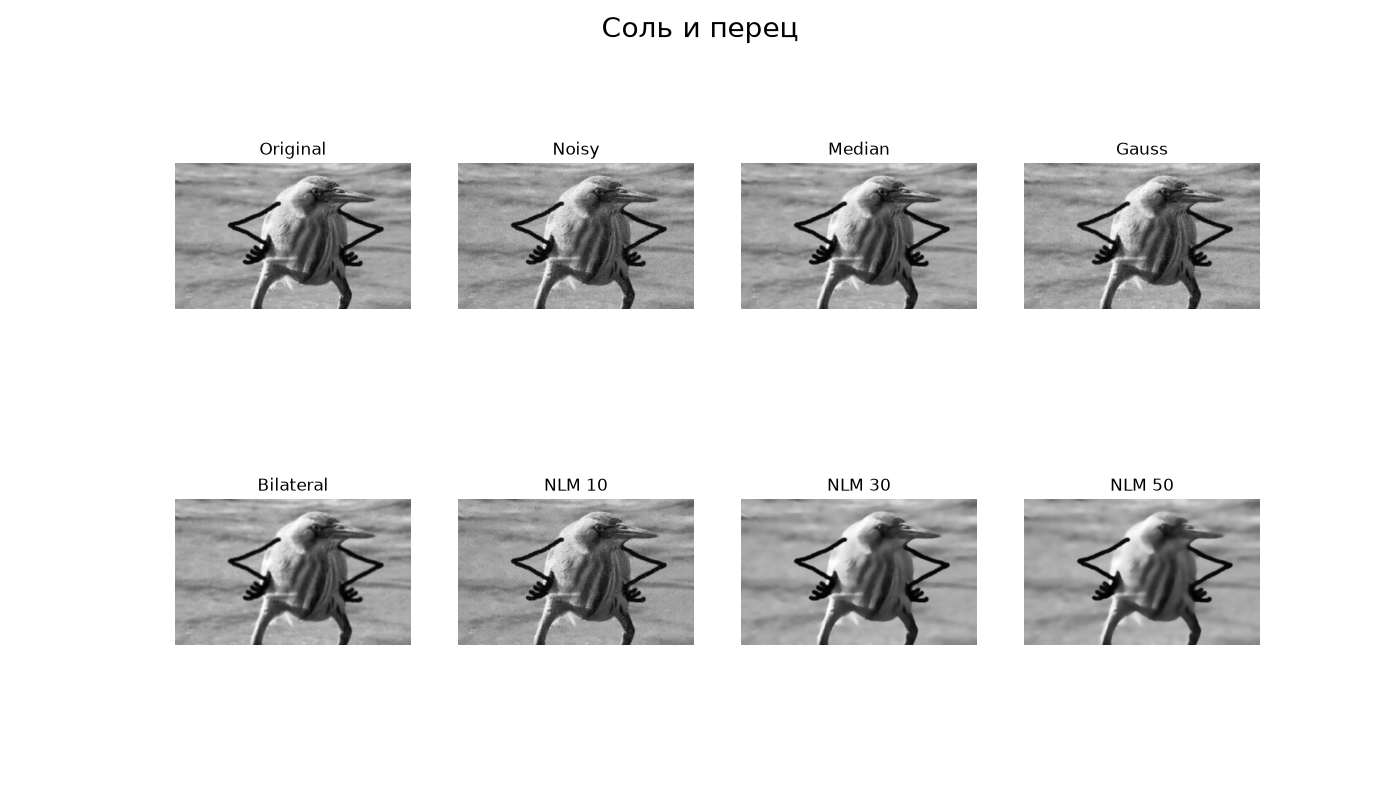
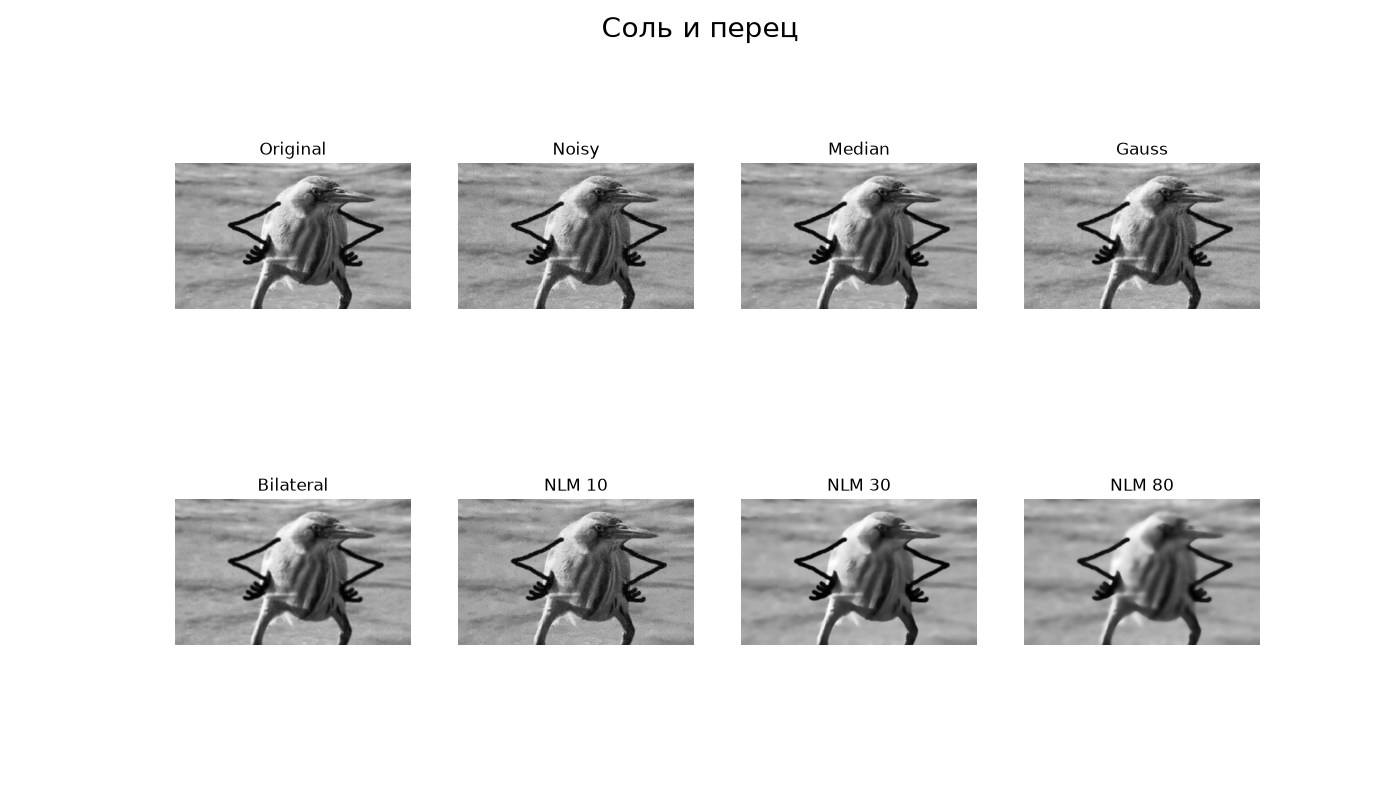
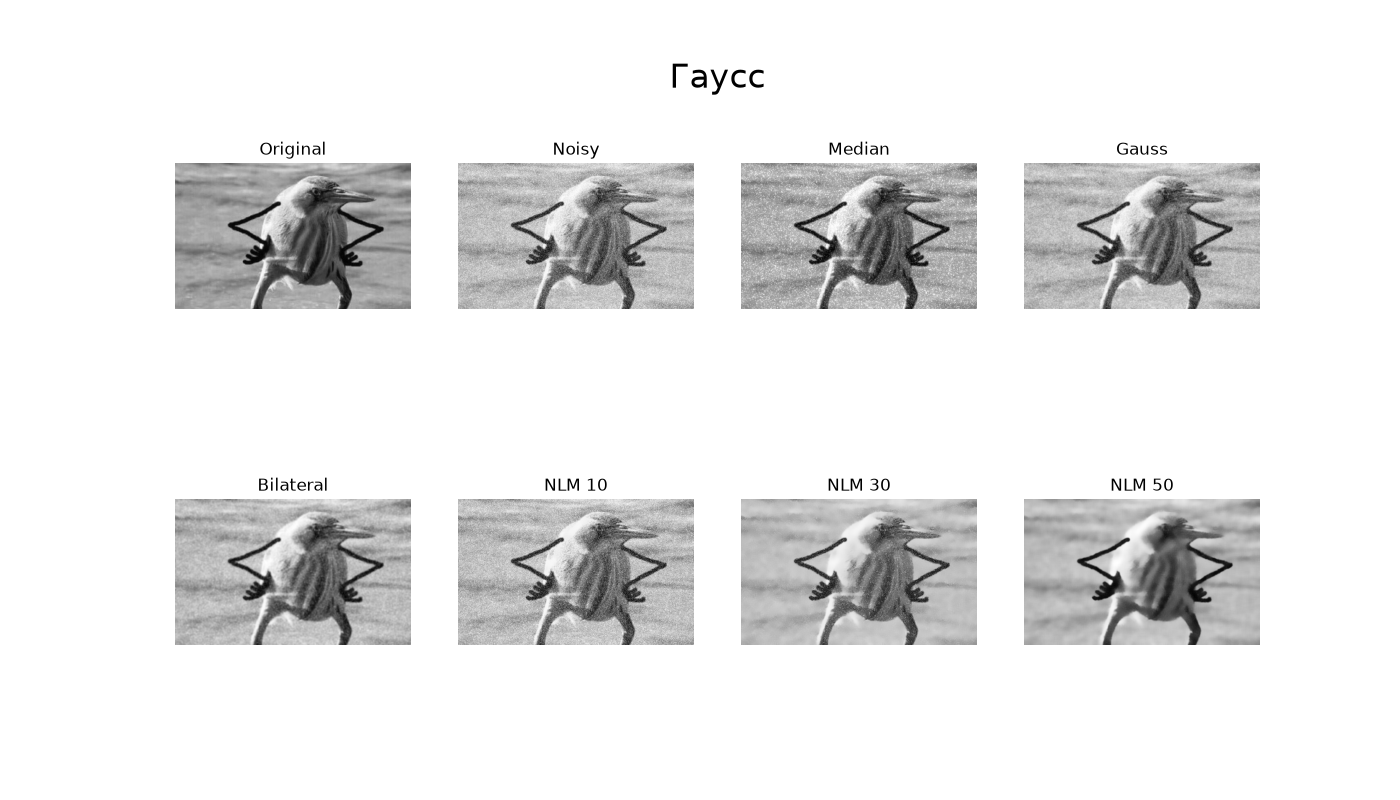
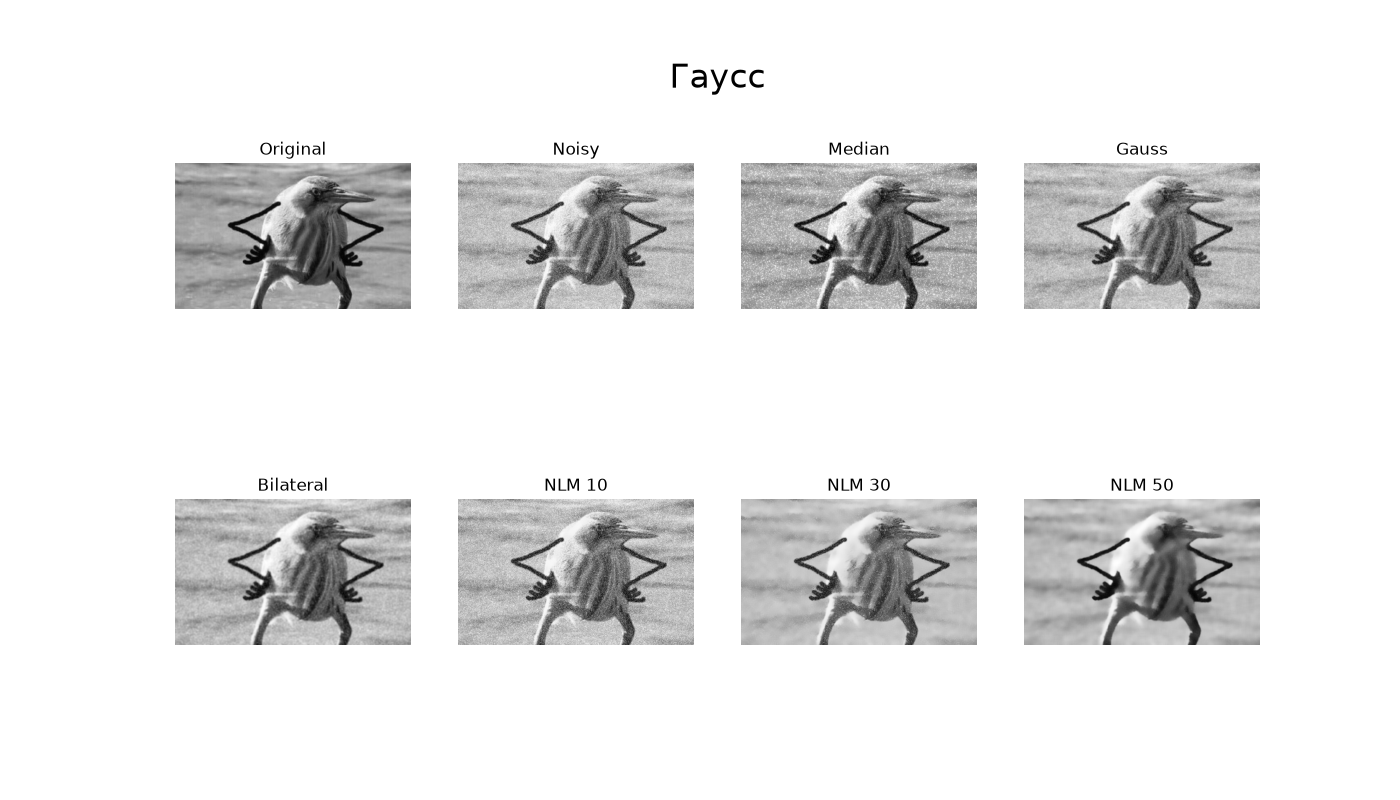
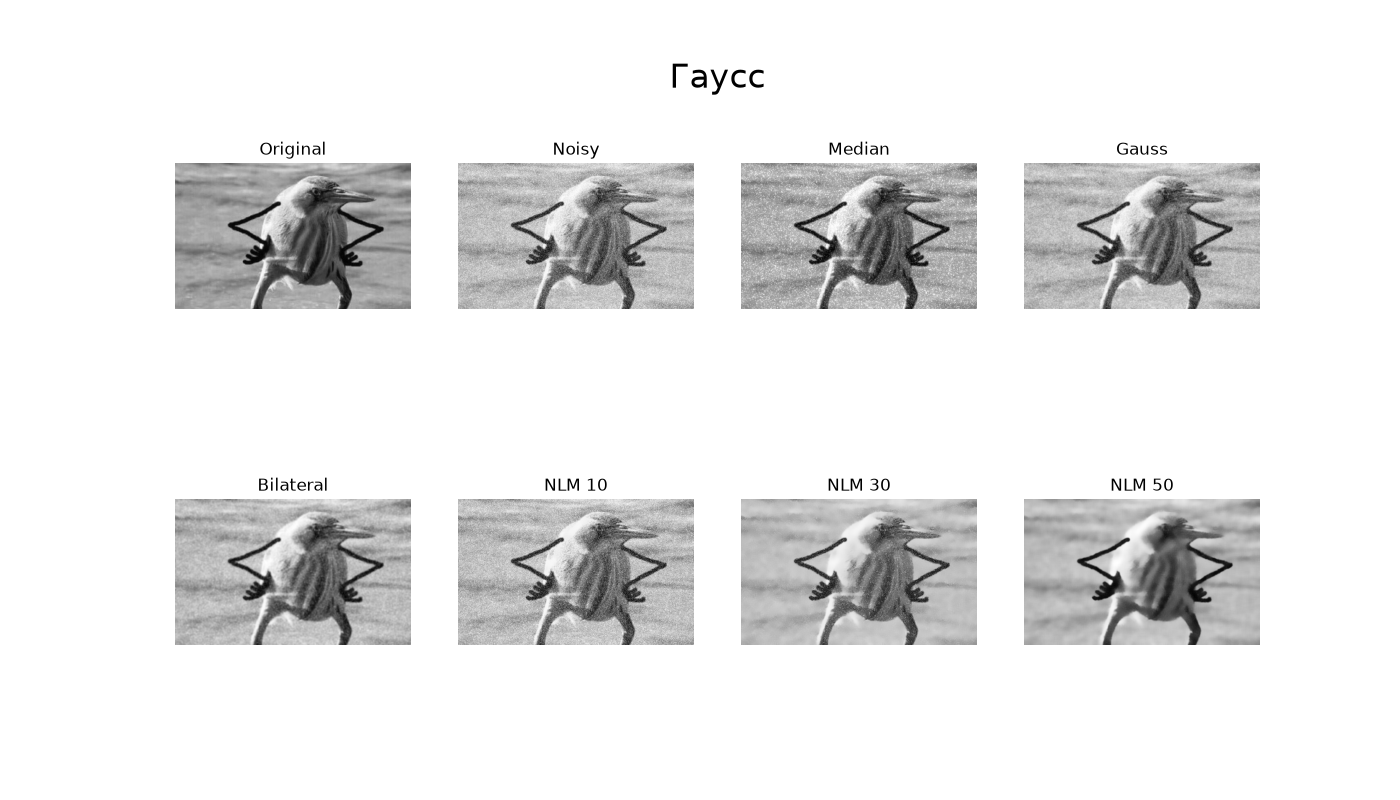
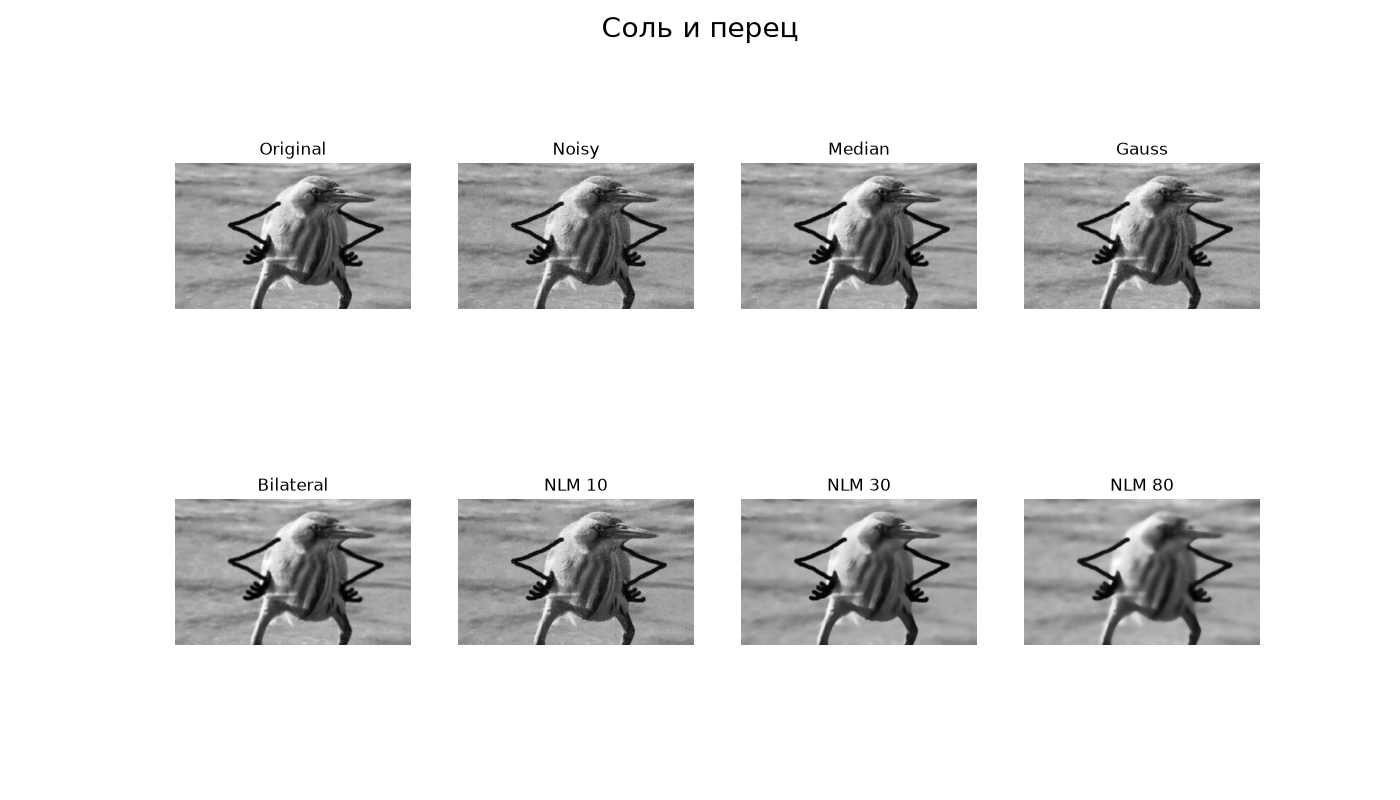
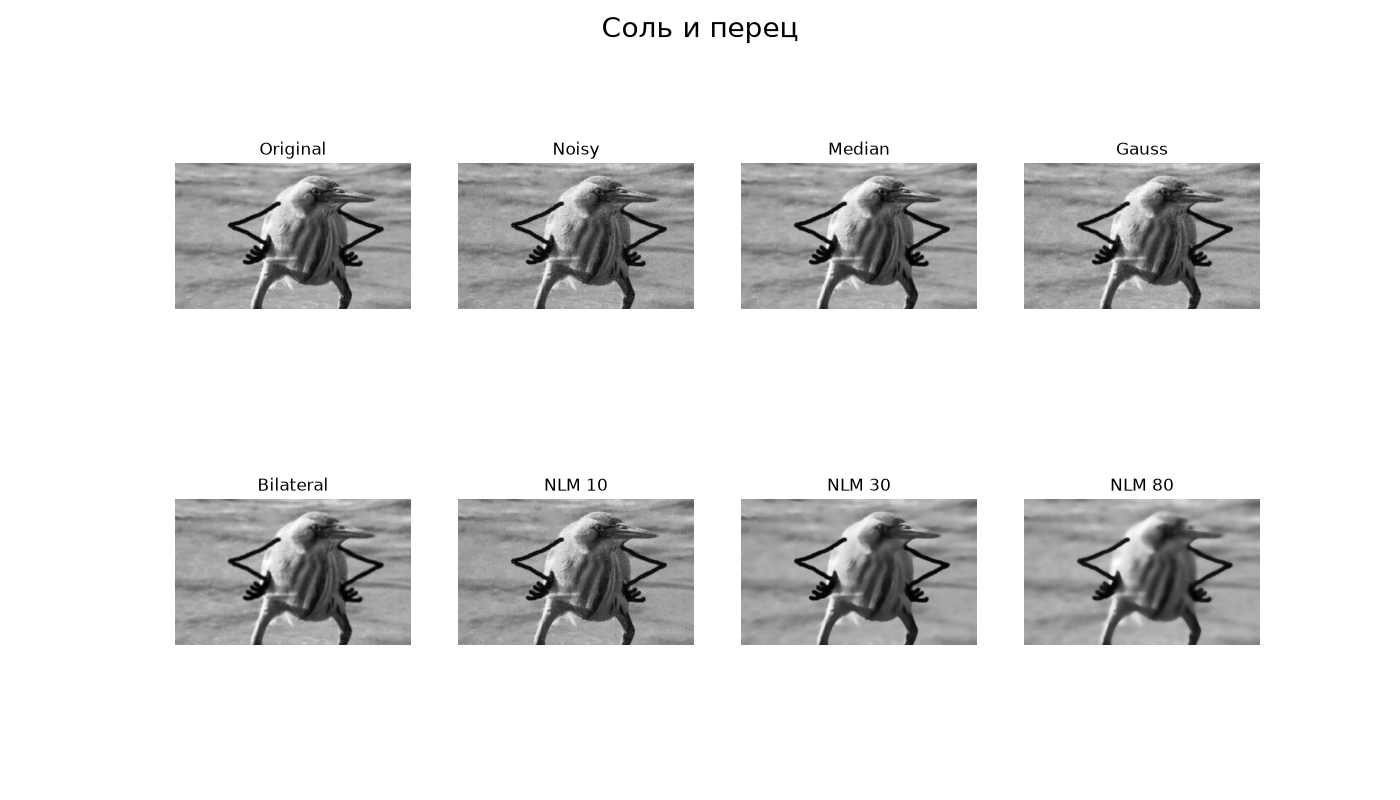

In [ ]:
#Salt and Pepper:
#Noisy SSIM: 0.541 MSE: 371.997
#Median SSIM: 0.989 MSE: 2.297
#Gauss SSIM: 0.830 MSE: 34.058
#Bilateral SSIM: 0.904 MSE: 27.766
#NLM 10 SSIM: 0.600 MSE: 310.560
#NLM 30 SSIM: 0.861 MSE: 40.687
#NLM 50 SSIM: 0.836 MSE: 59.783
#NLM 80 SSIM: 0.811 MSE: 89.717

Выводы:
-Гаусс шум
В нем лучше всего показали себя "Нелокальные Срдение" SSIM: 0.758. MSE в его случае - 1167.
-Соль и Перец
В данном случае лучше всего себя показал медианный фильтр. Median SSIM: 0.989 MSE: 2.305.
Для получения лучшего результата требуется подбирать индивидуальный фильтр и его параметры.